# ER 图随机基准：GES / GOLEM / CD

随机生成 ER 图，对比 GES、GOLEM、CD（cd_A）三种算法，报告 CPDAG_SHD、MEC 匹配率、目标函数变化及运行时间。

In [2]:
# 1) 环境与导入
import os
import sys
import time
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import expm

# ── 仓库根目录 ───────────────────────────────────────────────────────────────
def _find_repo_root(start: str) -> str:
    """向上遍历目录，找到包含 synthetic_dataset.py 的仓库根目录。"""
    current = os.path.abspath(start)
    for _ in range(10):
        if os.path.exists(os.path.join(current, 'synthetic_dataset.py')):
            return current
        parent = os.path.dirname(current)
        if parent == current:
            break
        current = parent
    # fallback: 从 __file__ 或 cwd 向上三级
    return os.path.abspath(os.path.join(start, '..', '..', '..'))

REPO_ROOT = _find_repo_root(os.getcwd())

if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

# ── 核心依赖 ─────────────────────────────────────────────────────────────────
from MEC import is_in_markov_equiv_class
from synthetic_dataset import SyntheticDataset

# ── CD 算法（cd_A / cd_A_epoch）──────────────────────────────────────────────
from coordinate_descent.coordinate0 import dag_coordinate_descent_l0 as cd_A
from coordinate_descent.coordinate0 import dag_coordinate_descent_l0_epoch as cd_A_epoch
from coordinate_descent.coordinate0 import f as cd_A_objective

# ── CD 算法（cd_B / cd_B_epoch）──────────────────────────────────────────────
from coordinate_descent.cd_B import dag_coordinate_descent_B as cd_B_run
from coordinate_descent.cd_B import dag_coordinate_descent_B_epoch as cd_B_epoch_run
from coordinate_descent.cd_B import f_B as cd_B_objective

# ── CD 算法（cd_BOmega / cd_BOmega_epoch）────────────────────────────────────
from coordinate_descent.cd_B_Omega import dag_coordinate_descent_BOmega as cd_BOmega_run
from coordinate_descent.cd_B_Omega import dag_coordinate_descent_BOmega_epoch as cd_BOmega_epoch_run
from coordinate_descent.cd_B_Omega import ell as cd_BOmega_objective
from coordinate_descent.cd_B_Omega import update_Omega_closed_form

# ── GOLEM（可选）────────────────────────────────────────────────────────────
GOLEM_IMPORT_ERROR = None
try:
    golem_src = os.path.join(REPO_ROOT, 'golemMain', 'src')
    if golem_src not in sys.path:
        sys.path.append(golem_src)
    from golem import golem as golem_fit
    HAS_GOLEM = True
except Exception as _e:
    HAS_GOLEM = False
    GOLEM_IMPORT_ERROR = _e

# ── GES（可选）──────────────────────────────────────────────────────────────
GES_IMPORT_ERROR = None
try:
    from causallearn.search.ScoreBased.GES import ges as ges_fit
    HAS_GES = True
except Exception as _e:
    HAS_GES = False
    GES_IMPORT_ERROR = _e

# ── CPDAG-SHD（可选，需 R / cdt）────────────────────────────────────────────
try:
    toolbox_path = os.path.join(REPO_ROOT, 'toolbox')
    if toolbox_path not in sys.path:
        sys.path.append(toolbox_path)
    from cdt.metrics import SHD_CPDAG as _SHD_CPDAG
    HAS_CPDAG_SHD = True
except Exception:
    _SHD_CPDAG = None
    HAS_CPDAG_SHD = False

print('REPO_ROOT       :', REPO_ROOT)
print('HAS_GOLEM       :', HAS_GOLEM)
print('HAS_GES         :', HAS_GES)
print('HAS_CPDAG_SHD   :', HAS_CPDAG_SHD)
if not HAS_GOLEM:  print('  GOLEM error    :', GOLEM_IMPORT_ERROR)
if not HAS_GES:    print('  GES error      :', GES_IMPORT_ERROR)

c:\Users\super\DAG\experiments\notebooks\benchmark



No GPU automatically detected. Setting SETTINGS.GPU to 0, and SETTINGS.NJOBS to cpu_count.


REPO_ROOT       : c:\Users\super\DAG
HAS_GOLEM       : True
HAS_GES         : True
HAS_CPDAG_SHD   : True


In [3]:
# 2) Utility functions

@dataclass
class TrialRow:
    d: int
    n_samples: int
    trial_id: int
    seed: int
    algorithm: str
    status: str
    runtime_sec: float
    mec_match: float
    shd: float          # Structural Hamming Distance (DAG-level)
    cpdag_shd: float    # CPDAG-SHD (requires R/cdt; NaN if unavailable)
    n_edges_true: int
    n_edges_est: int
    score_start: float
    score_end: float
    score_delta: float
    message: str


def weight_to_binary_adj(W: np.ndarray, threshold: float = 0.05) -> np.ndarray:
    G = (np.abs(W) > threshold).astype(int)
    np.fill_diagonal(G, 0)
    return G


def shd_score(G_true: np.ndarray, G_est: np.ndarray) -> float:
    """Structural Hamming Distance between two binary adjacency matrices."""
    G_true = np.asarray(G_true, dtype=int)
    G_est  = np.asarray(G_est,  dtype=int)
    d = G_true.shape[0]
    dist = 0
    for i in range(d):
        for j in range(i + 1, d):
            if (G_true[i, j] != G_est[i, j]) or (G_true[j, i] != G_est[j, i]):
                dist += 1
    return float(dist)


def cpdag_shd_score(G_true: np.ndarray, G_est: np.ndarray) -> float:
    """CPDAG-SHD via cdt; returns NaN if cdt / R is unavailable."""
    if not HAS_CPDAG_SHD:
        return np.nan
    try:
        return float(_SHD_CPDAG(G_true.astype(int), G_est.astype(int)))
    except Exception:
        return np.nan


def ges_graph_to_adj(g: np.ndarray) -> np.ndarray:
    """Convert causal-learn GES mixed-graph matrix to a binary adjacency matrix."""
    g = np.asarray(g)
    d = g.shape[0]
    A = np.zeros((d, d), dtype=int)
    for i in range(d):
        for j in range(i + 1, d):
            a, b = g[i, j], g[j, i]
            if a == -1 and b == 1:
                A[i, j] = 1
            elif a == 1 and b == -1:
                A[j, i] = 1
            elif a == -1 and b == -1:
                A[i, j] = 1; A[j, i] = 1
            elif a != 0 or b != 0:
                A[i, j] = int(a != 0)
                A[j, i] = int(b != 0)
    np.fill_diagonal(A, 0)
    return A


def golem_score_approx(X: np.ndarray, B: np.ndarray,
                        lambda_1: float, lambda_2: float,
                        equal_variances: bool, eps: float = 1e-12) -> float:
    Xc = X - X.mean(axis=0, keepdims=True)
    d = Xc.shape[1]
    R = Xc - Xc @ B
    if equal_variances:
        likelihood = 0.5 * d * np.log(max(float(np.sum(R * R)), eps))
    else:
        col_sq = np.sum(R * R, axis=0)
        likelihood = 0.5 * float(np.sum(np.log(np.maximum(col_sq, eps))))
    sign, logdet = np.linalg.slogdet(np.eye(d) - B)
    if sign <= 0 or not np.isfinite(logdet):
        return np.nan
    likelihood -= float(logdet)
    l1 = float(np.sum(np.abs(B)))
    h = float(np.trace(expm(B * B)) - d)
    return likelihood + lambda_1 * l1 + lambda_2 * h


# ── Algorithm dispatcher ──────────────────────────────────────────────────────
def run_algorithm(
    algorithm: str,
    X: np.ndarray,
    S: np.ndarray,
    G_true: np.ndarray,
    d: int,
    seed: int,
    cfg: dict,
) -> dict:
    t0 = time.perf_counter()
    try:
        # ── CD (cd_A) ─────────────────────────────────────────────────────────
        if algorithm == 'cd_A' or algorithm.startswith('cd_A_lam'):
            _lam = (float(algorithm[len('cd_A_lam'):])
                    if algorithm.startswith('cd_A_lam')
                    else cfg['lambda_l0'])
            B_est, G_est, obj_end = cd_A(
                S=S,
                T=cfg['cd_steps'],
                seed=seed,
                threshold=cfg['threshold'],
                lambda_l0=_lam,
            )
            B_est = np.asarray(B_est)
            score_start = float(cd_A_objective(np.eye(d), S))
            score_end   = float(obj_end)

        # ── CD (cd_A_epoch) ───────────────────────────────────────────────────
        elif algorithm == 'cd_A_epoch':
            A_est, G_est, obj_end, _ = cd_A_epoch(
                S=S,
                n_epochs=cfg['n_epochs'],
                seed=seed,
                threshold=cfg['threshold'],
                lambda_l0=cfg['lambda_l0'],
            )
            B_est = np.asarray(A_est)
            score_start = float(cd_A_objective(np.eye(d), S))
            score_end   = float(obj_end)

        # ── CD (cd_B) ─────────────────────────────────────────────────────────
        elif algorithm == 'cd_B':
            B_est, G_est, obj_end, _ = cd_B_run(
                S=S,
                T=cfg['cd_steps'],
                seed=seed,
                threshold=cfg['threshold'],
                lambda_l0=cfg['lambda_l0'],
            )
            B_est = np.asarray(B_est)
            score_start = float(cd_B_objective(np.zeros((d, d)), S))
            score_end   = float(obj_end)

        # ── CD (cd_B_epoch) ───────────────────────────────────────────────────
        elif algorithm == 'cd_B_epoch':
            B_est, G_est, obj_end, _, _ = cd_B_epoch_run(
                S=S,
                n_epochs=cfg['n_epochs'],
                seed=seed,
                threshold=cfg['threshold'],
                lambda_l0=cfg['lambda_l0'],
            )
            B_est = np.asarray(B_est)
            score_start = float(cd_B_objective(np.zeros((d, d)), S))
            score_end   = float(obj_end)

        # ── CD (cd_BOmega) ────────────────────────────────────────────────────
        elif algorithm == 'cd_BOmega':
            Omega_init = np.diag(np.diag(S))
            B_est, G_est, obj_end, _ = cd_BOmega_run(
                S=S,
                Omega=Omega_init,
                T=cfg['cd_steps'],
                seed=seed,
                threshold=cfg['threshold'],
                lambda_l0=cfg['lambda_l0'],
            )
            B_est = np.asarray(B_est)
            score_start = float(cd_BOmega_objective(np.zeros((d, d)), Omega_init, S))
            score_end   = float(obj_end)

        # ── CD (cd_BOmega_epoch) ──────────────────────────────────────────────
        elif algorithm == 'cd_BOmega_epoch':
            Omega_init = np.diag(np.diag(S))
            B_est, G_est, obj_end, _, _ = cd_BOmega_epoch_run(
                S=S,
                Omega=Omega_init,
                n_epochs=cfg['n_epochs'],
                seed=seed,
                threshold=cfg['threshold'],
                lambda_l0=cfg['lambda_l0'],
            )
            B_est = np.asarray(B_est)
            score_start = float(cd_BOmega_objective(np.zeros((d, d)), Omega_init, S))
            score_end   = float(obj_end)

        # ── GOLEM ─────────────────────────────────────────────────────────────
        elif algorithm == 'golem':
            if not HAS_GOLEM:
                return {'status': 'unavailable', 'runtime_sec': np.nan,
                        'message': str(GOLEM_IMPORT_ERROR)}
            B0 = np.zeros((d, d))
            score_start = golem_score_approx(
                X, B0, cfg['golem_lambda1'], cfg['golem_lambda2'],
                cfg['golem_equal_variances'],
            )
            B_est = golem_fit(
                X,
                lambda_1=cfg['golem_lambda1'],
                lambda_2=cfg['golem_lambda2'],
                equal_variances=cfg['golem_equal_variances'],
                num_iter=cfg['golem_num_iter'],
                learning_rate=cfg['golem_learning_rate'],
                seed=seed,
            )
            B_est = np.asarray(B_est)
            G_est = weight_to_binary_adj(B_est, threshold=cfg['threshold'])
            score_end = golem_score_approx(
                X, B_est, cfg['golem_lambda1'], cfg['golem_lambda2'],
                cfg['golem_equal_variances'],
            )

        # ── GES ───────────────────────────────────────────────────────────────
        elif algorithm == 'ges':
            if not HAS_GES:
                return {'status': 'unavailable', 'runtime_sec': np.nan,
                        'message': str(GES_IMPORT_ERROR)}
            ges_rec = ges_fit(X)
            G_est   = ges_graph_to_adj(ges_rec['G'].graph)
            B_est   = None
            score_start = np.nan
            score_end   = np.nan

        else:
            return {'status': 'failed', 'runtime_sec': np.nan,
                    'message': f'Unknown algorithm: {algorithm}'}

        t1 = time.perf_counter()
        mec   = float(int(is_in_markov_equiv_class(G_true, G_est)))
        shd   = shd_score(G_true, G_est)
        cshd  = cpdag_shd_score(G_true, G_est)
        delta = float(score_end - score_start) if (
            np.isfinite(score_start) and np.isfinite(score_end)
        ) else np.nan

        return {
            'status':       'ok',
            'runtime_sec':  float(t1 - t0),
            'message':      '',
            'B_est':        B_est,
            'G_est':        G_est,
            'mec_match':    mec,
            'shd':          shd,
            'cpdag_shd':    cshd,
            'n_edges_est':  int(G_est.sum()),
            'score_start':  float(score_start) if np.isfinite(score_start) else np.nan,
            'score_end':    float(score_end)   if np.isfinite(score_end)   else np.nan,
            'score_delta':  delta,
        }

    except Exception as exc:
        t1 = time.perf_counter()
        return {'status': 'failed', 'runtime_sec': float(t1 - t0), 'message': str(exc)}


# ── Aggregation ───────────────────────────────────────────────────────────────
def summarize(df: pd.DataFrame) -> pd.DataFrame:
    if len(df) == 0:
        return pd.DataFrame()
    rows = []
    for (d, n, alg), sub in df.groupby(['d', 'n_samples', 'algorithm']):
        ok = sub[sub['status'] == 'ok']
        rows.append({
            'd':                 int(d),
            'n_samples':         int(n),
            'algorithm':         str(alg),
            'n_trials':          len(sub),
            'n_ok':              len(ok),
            'mec_match_rate':    float(ok['mec_match'].mean())    if len(ok) else np.nan,
            'shd_mean':          float(ok['shd'].mean())          if len(ok) else np.nan,
            'shd_std':           float(ok['shd'].std())           if len(ok) else np.nan,
            'cpdag_shd_mean':    float(ok['cpdag_shd'].mean())    if len(ok) else np.nan,
            'cpdag_shd_std':     float(ok['cpdag_shd'].std())     if len(ok) else np.nan,
            'runtime_sec_mean':  float(ok['runtime_sec'].mean())  if len(ok) else np.nan,
            'score_delta_mean':  float(ok['score_delta'].mean())  if len(ok) else np.nan,
            'n_edges_est_mean':  float(ok['n_edges_est'].mean())  if len(ok) else np.nan,
            'n_edges_true_mean': float(ok['n_edges_true'].mean()) if len(ok) else np.nan,
            'status_counts':     str(dict(sub['status'].value_counts())),
        })
    return pd.DataFrame(rows).sort_values(['d', 'n_samples', 'algorithm']).reset_index(drop=True)


print('Utility functions defined.')

Utility functions defined.


In [4]:
# 3) 实验配置
CFG = {
    # ── 随机图参数 ─────────────────────────────────────────────────────────
    'trials':       3,          # 每组设定重复次数
    'seed':         42,
    'd_list':       [20, 30, 40, 50],   # 节点数列表
    'n_list':       [20000],  # 样本量列表
    'degree':       3.0,        # ER 图期望度（每节点平均边数）
    'noise_type':   'gaussian_nv',  # 噪声类型
    'b_scale':      2.0,        # 边权重缩放

    # ── 通用 ──────────────────────────────────────────────────────────────
    'threshold':    0.05,       # 权重绝对值阈值（二值化）

    # ── CD 步数参数（cd_A / cd_B / cd_BOmega）─────────────────────────────
    'cd_steps':     100000,
    'lambda_l0':    0.1,

    # ── CD epoch 参数（cd_A_epoch / cd_B_epoch / cd_BOmega_epoch）──────────
    'n_epochs':     500,

    # ── GOLEM 参数 ─────────────────────────────────────────────────────────
    'golem_num_iter':       100000,
    'golem_learning_rate':  1e-3,
    'golem_lambda1':        2e-3,
    'golem_lambda2':        5.0,
    'golem_equal_variances': False,
}

# 要对比的算法
# 可选：'cd_A_epoch', 'cd_B', 'cd_B_epoch', 'cd_BOmega', 'cd_BOmega_epoch'，'GES'
ALGORITHMS = ['golem', 'cd_A', 'cd_B', 'cd_BOmega']

# 结果保存目录
OUT_DIR = os.path.join(REPO_ROOT, 'experiments', 'results')
os.makedirs(OUT_DIR, exist_ok=True)

# 每个 trial 的矩阵日志（键：(algorithm, d, n_samples, trial_id)）
MATRIX_STORE: dict = {}

print('配置完成。')
print('算法列表 :', ALGORITHMS)
print('d_list   :', CFG['d_list'])
print('n_list   :', CFG['n_list'])
print('OUT_DIR  :', OUT_DIR)
print('trials   :', CFG['trials'])

配置完成。
算法列表 : ['golem', 'cd_A', 'cd_B', 'cd_BOmega']
d_list   : [20, 30, 40, 50]
n_list   : [20000]
OUT_DIR  : c:\Users\super\DAG\experiments\results
trials   : 3


In [5]:
# 4) Per-algorithm benchmark runner

def _print_matrix(name: str, M: Optional[np.ndarray], precision: int = 3) -> None:
    if M is None:
        print(f'  {name}: N/A')
        return
    with np.printoptions(precision=precision, suppress=True, linewidth=140):
        lines = str(M).splitlines()
    print(f'  {name} (shape={M.shape}):')
    for ln in lines:
        print('   ', ln)


def run_benchmark(
    algorithm_name: str,
    cfg: dict,
    d_list: Optional[List[int]] = None,
    n_list: Optional[List[int]] = None,
    print_matrices: bool = False,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    global MATRIX_STORE
    if d_list is None:
        d_list = cfg['d_list']
    if n_list is None:
        n_list = cfg['n_list']

    rng  = np.random.default_rng(cfg['seed'])
    rows: List[TrialRow] = []

    for d in d_list:
        for n in n_list:
            seeds = rng.integers(0, 10**9, size=cfg['trials'])
            print(f'\n[{algorithm_name}] d={d}  n={n}  trials={cfg["trials"]}')

            for trial_idx, seed in enumerate(seeds, start=1):
                dataset = SyntheticDataset(
                    n=n, d=d,
                    graph_type='ER',
                    degree=cfg['degree'],
                    noise_type=cfg['noise_type'],
                    B_scale=cfg['b_scale'],
                    seed=int(seed),
                )
                X      = dataset.X
                S      = X.T @ X / X.shape[0]
                B_true = dataset.B
                G_true = weight_to_binary_adj(B_true, threshold=0.0)
                n_edges_true = int(G_true.sum())

                res = run_algorithm(algorithm_name, X, S, G_true, d, int(seed), cfg)

                row = TrialRow(
                    d=d,
                    n_samples=n,
                    trial_id=trial_idx,
                    seed=int(seed),
                    algorithm=algorithm_name,
                    status=str(res['status']),
                    runtime_sec=float(res['runtime_sec']) if ('runtime_sec' in res and pd.notna(res['runtime_sec'])) else np.nan,
                    mec_match=float(res.get('mec_match', np.nan)),
                    shd=float(res.get('shd', np.nan)),
                    cpdag_shd=float(res.get('cpdag_shd', np.nan)),
                    n_edges_true=n_edges_true,
                    n_edges_est=int(res.get('n_edges_est', -1)),
                    score_start=float(res.get('score_start', np.nan)),
                    score_end=float(res.get('score_end', np.nan)),
                    score_delta=float(res.get('score_delta', np.nan)),
                    message=str(res.get('message', '')),
                )
                rows.append(row)

                B_est_out = res.get('B_est', None)
                G_est_out = res.get('G_est', None)

                key = (algorithm_name, d, n, trial_idx)
                MATRIX_STORE[key] = {
                    'B_true': B_true, 'G_true': G_true,
                    'B_est':  B_est_out, 'G_est': G_est_out,
                }

                if res['status'] == 'ok':
                    cshd_str = f"{res['cpdag_shd']:.1f}" if pd.notna(res['cpdag_shd']) else 'NaN'
                    print(
                        f"  trial {trial_idx:03d}/{cfg['trials']}  seed={int(seed):9d}"
                        f"  t={res['runtime_sec']:.2f}s"
                        f"  mec={res['mec_match']:.0f}"
                        f"  shd={res['shd']:.0f}"
                        f"  cpdag_shd={cshd_str}"
                        f"  edges_true={n_edges_true}  edges_est={res.get('n_edges_est', '?')}"
                    )
                    if print_matrices:
                        print(f'  ── matrices [trial {trial_idx}] ──')
                        _print_matrix('B_true (ground truth weights)', B_true)
                        _print_matrix('G_true (ground truth adjacency)', G_true)
                        _print_matrix('B_est  (estimated weights)', B_est_out)
                        _print_matrix('G_est  (estimated adjacency)', G_est_out)
                        print()
                else:
                    print(f"  trial {trial_idx:03d}/{cfg['trials']}  seed={int(seed):9d}  [{res['status']}] {res.get('message', '')}")

    df_trials  = pd.DataFrame([r.__dict__ for r in rows])
    df_summary = summarize(df_trials)

    tag   = f'er_benchmark_{algorithm_name}'
    f_tri = os.path.join(OUT_DIR, f'{tag}_trials.csv')
    f_sum = os.path.join(OUT_DIR, f'{tag}_summary.csv')
    df_trials.to_csv(f_tri, index=False)
    df_summary.to_csv(f_sum, index=False)
    print(f'\nSaved: {f_tri}')
    print(f'Saved: {f_sum}')

    print('\n=== Summary ===')
    display(df_summary)
    return df_trials, df_summary

print('run_benchmark defined.')


run_benchmark defined.


In [5]:
# # 5) 运行 GES
# df_trials_ges, df_summary_ges = run_benchmark('ges', CFG)

In [12]:
# 6) 运行 GOLEM
df_trials_golem, df_summary_golem = run_benchmark('golem', CFG)


[golem] d=20  n=20000  trials=3

  trial 001/3  seed= 89250953  t=252.60s  mec=0  shd=89  cpdag_shd=89.0  edges_true=28  edges_est=84
  trial 002/3  seed=773956048  t=240.68s  mec=0  shd=91  cpdag_shd=92.0  edges_true=30  edges_est=95
  trial 003/3  seed=654571518  t=240.80s  mec=0  shd=104  cpdag_shd=105.0  edges_true=34  edges_est=99

[golem] d=30  n=20000  trials=3
  trial 001/3  seed=438878439  t=320.68s  mec=0  shd=161  cpdag_shd=162.0  edges_true=51  edges_est=165
  trial 002/3  seed=433015235  t=323.77s  mec=0  shd=209  cpdag_shd=213.0  edges_true=42  edges_est=222
  trial 003/3  seed=858597919  t=328.88s  mec=0  shd=91  cpdag_shd=90.0  edges_true=32  edges_est=96

[golem] d=40  n=20000  trials=3
  trial 001/3  seed=201469535  t=403.20s  mec=0  shd=306  cpdag_shd=308.0  edges_true=68  edges_est=291
  trial 002/3  seed= 94177347  t=399.25s  mec=0  shd=203  cpdag_shd=206.0  edges_true=58  edges_est=201
  trial 003/3  seed=526478978  t=463.83s  mec=0  shd=229  cpdag_shd=231.0  edg

,d,n_samples,algorithm,n_trials,n_ok,mec_match_rate,shd_mean,shd_std,cpdag_shd_mean,cpdag_shd_std,runtime_sec_mean,score_delta_mean,n_edges_est_mean,n_edges_true_mean,status_counts
0,20,20000,golem,3,3,0.0,94.666667,8.144528,95.333333,8.504901,244.694132,-26.087852,92.666667,30.666667,{'ok': 3}
1,30,20000,golem,3,3,0.0,153.666667,59.340823,155.000000,61.798058,324.441892,-53.808776,161.000000,41.666667,{'ok': 3}
2,40,20000,golem,3,3,0.0,246.000000,53.563047,248.333333,53.163271,422.092390,-57.541083,239.666667,61.333333,{'ok': 3}
3,50,20000,golem,3,3,0.0,401.666667,98.358189,404.000000,99.080775,549.992498,-92.384239,413.333333,79.666667,{'ok': 3}


In [6]:
# 7) 运行 CD（cd_A）
df_trials_cd, df_summary_cd = run_benchmark('cd_A', CFG)


[cd_A] d=20  n=20000  trials=3


KeyboardInterrupt: 

In [7]:
# 7f) 运行 cd_A lambda 变体 (λ=0, 0.1, 0.2)
_lam_variants = [0.0, 0.1, 0.2]
for _lam in _lam_variants:
    _alg_name = f'cd_A_lam{_lam}'
    _cfg = {**CFG, 'lambda_l0': _lam}
    _df_t, _df_s = run_benchmark(_alg_name, _cfg)
    globals()[f'df_trials_{_alg_name.replace(".", "_")}']  = _df_t
    globals()[f'df_summary_{_alg_name.replace(".", "_")}'] = _df_s



[cd_A_lam0.0] d=20  n=20000  trials=3
  trial 001/3  seed= 89250953  t=61.76s  mec=0  shd=60  cpdag_shd=59.0  edges_true=28  edges_est=83
  trial 002/3  seed=773956048  t=61.88s  mec=0  shd=44  cpdag_shd=42.0  edges_true=30  edges_est=69
  trial 003/3  seed=654571518  t=64.07s  mec=0  shd=36  cpdag_shd=37.0  edges_true=34  edges_est=65

[cd_A_lam0.0] d=30  n=20000  trials=3
  trial 001/3  seed=438878439  t=78.00s  mec=0  shd=167  cpdag_shd=167.0  edges_true=51  edges_est=209
  trial 002/3  seed=433015235  t=87.17s  mec=0  shd=128  cpdag_shd=127.0  edges_true=42  edges_est=164
  trial 003/3  seed=858597919  t=75.84s  mec=0  shd=92  cpdag_shd=91.0  edges_true=32  edges_est=111

[cd_A_lam0.0] d=40  n=20000  trials=3
  trial 001/3  seed=201469535  t=83.37s  mec=0  shd=196  cpdag_shd=197.0  edges_true=68  edges_est=261
  trial 002/3  seed= 94177347  t=90.72s  mec=0  shd=248  cpdag_shd=249.0  edges_true=58  edges_est=292
  trial 003/3  seed=526478978  t=81.51s  mec=0  shd=176  cpdag_shd=179

,d,n_samples,algorithm,n_trials,n_ok,mec_match_rate,shd_mean,shd_std,cpdag_shd_mean,cpdag_shd_std,runtime_sec_mean,score_delta_mean,n_edges_est_mean,n_edges_true_mean,status_counts
0,20,20000,cd_A_lam0.0,3,3,0.0,46.666667,12.220202,46.000000,11.532563,62.569296,-1.269855e+04,72.333333,30.666667,{'ok': 3}
1,30,20000,cd_A_lam0.0,3,3,0.0,129.000000,37.509999,128.333333,38.017540,80.334674,-3.860153e+06,161.333333,41.666667,{'ok': 3}
2,40,20000,cd_A_lam0.0,3,3,0.0,206.666667,37.166293,208.333333,36.350149,85.198406,-2.346043e+05,258.333333,61.333333,{'ok': 3}
3,50,20000,cd_A_lam0.0,3,3,0.0,375.333333,108.260488,377.333333,109.769455,112.218810,-3.290324e+06,434.333333,79.666667,{'ok': 3}



[cd_A_lam0.1] d=20  n=20000  trials=3
  trial 001/3  seed= 89250953  t=60.65s  mec=0  shd=36  cpdag_shd=35.0  edges_true=28  edges_est=51
  trial 002/3  seed=773956048  t=60.25s  mec=0  shd=36  cpdag_shd=35.0  edges_true=30  edges_est=50
  trial 003/3  seed=654571518  t=60.50s  mec=0  shd=16  cpdag_shd=18.0  edges_true=34  edges_est=43

[cd_A_lam0.1] d=30  n=20000  trials=3
  trial 001/3  seed=438878439  t=75.84s  mec=0  shd=128  cpdag_shd=128.0  edges_true=51  edges_est=152
  trial 002/3  seed=433015235  t=87.63s  mec=0  shd=107  cpdag_shd=105.0  edges_true=42  edges_est=135
  trial 003/3  seed=858597919  t=73.38s  mec=0  shd=60  cpdag_shd=59.0  edges_true=32  edges_est=69

[cd_A_lam0.1] d=40  n=20000  trials=3
  trial 001/3  seed=201469535  t=84.55s  mec=0  shd=96  cpdag_shd=95.0  edges_true=68  edges_est=146
  trial 002/3  seed= 94177347  t=97.46s  mec=0  shd=198  cpdag_shd=198.0  edges_true=58  edges_est=226
  trial 003/3  seed=526478978  t=84.68s  mec=0  shd=105  cpdag_shd=106.0 

,d,n_samples,algorithm,n_trials,n_ok,mec_match_rate,shd_mean,shd_std,cpdag_shd_mean,cpdag_shd_std,runtime_sec_mean,score_delta_mean,n_edges_est_mean,n_edges_true_mean,status_counts
0,20,20000,cd_A_lam0.1,3,3,0.0,29.333333,11.547005,29.333333,9.814955,60.463684,-1.269624e+04,48.000000,30.666667,{'ok': 3}
1,30,20000,cd_A_lam0.1,3,3,0.0,98.333333,34.818577,97.333333,35.133080,78.951425,-3.860129e+06,118.666667,41.666667,{'ok': 3}
2,40,20000,cd_A_lam0.1,3,3,0.0,133.000000,56.471232,133.000000,56.559703,88.897223,-2.346008e+05,169.333333,61.333333,{'ok': 3}
3,50,20000,cd_A_lam0.1,3,3,0.0,285.666667,122.075113,287.000000,122.560189,980.160252,-3.290131e+06,330.000000,79.666667,{'ok': 3}



[cd_A_lam0.2] d=20  n=20000  trials=3
  trial 001/3  seed= 89250953  t=61.30s  mec=0  shd=35  cpdag_shd=34.0  edges_true=28  edges_est=47
  trial 002/3  seed=773956048  t=61.58s  mec=0  shd=32  cpdag_shd=30.0  edges_true=30  edges_est=46
  trial 003/3  seed=654571518  t=60.83s  mec=0  shd=25  cpdag_shd=25.0  edges_true=34  edges_est=45

[cd_A_lam0.2] d=30  n=20000  trials=3
  trial 001/3  seed=438878439  t=75.06s  mec=0  shd=121  cpdag_shd=121.0  edges_true=51  edges_est=135
  trial 002/3  seed=433015235  t=87.82s  mec=0  shd=94  cpdag_shd=95.0  edges_true=42  edges_est=117
  trial 003/3  seed=858597919  t=72.63s  mec=0  shd=56  cpdag_shd=54.0  edges_true=32  edges_est=64

[cd_A_lam0.2] d=40  n=20000  trials=3
  trial 001/3  seed=201469535  t=84.33s  mec=0  shd=96  cpdag_shd=96.0  edges_true=68  edges_est=139
  trial 002/3  seed= 94177347  t=92.78s  mec=0  shd=179  cpdag_shd=179.0  edges_true=58  edges_est=205
  trial 003/3  seed=526478978  t=83.94s  mec=0  shd=95  cpdag_shd=95.0  edg

,d,n_samples,algorithm,n_trials,n_ok,mec_match_rate,shd_mean,shd_std,cpdag_shd_mean,cpdag_shd_std,runtime_sec_mean,score_delta_mean,n_edges_est_mean,n_edges_true_mean,status_counts
0,20,20000,cd_A_lam0.2,3,3,0.0,30.666667,5.131601,29.666667,4.509250,61.236005,-1.269506e+04,46.000000,30.666667,{'ok': 3}
1,30,20000,cd_A_lam0.2,3,3,0.0,90.333333,32.654760,90.000000,33.778692,78.505204,-3.860124e+06,105.333333,41.666667,{'ok': 3}
2,40,20000,cd_A_lam0.2,3,3,0.0,123.333333,48.211340,123.333333,48.211340,87.017256,-2.345970e+05,152.666667,61.333333,{'ok': 3}
3,50,20000,cd_A_lam0.2,3,3,0.0,235.666667,102.510162,236.333333,102.812126,113.536485,-3.290650e+06,268.000000,79.666667,{'ok': 3}


In [ ]:
# 7a) 运行 cd_A_epoch
df_trials_cd_A_epoch, df_summary_cd_A_epoch = run_benchmark('cd_A_epoch', CFG)

In [12]:
# 7b) 运行 cd_B
df_trials_cd_B, df_summary_cd_B = run_benchmark('cd_B', CFG)


[cd_B] d=20  n=20000  trials=10
  trial 001/10  seed= 89250953  t=17.53s  mec=0  shd=90  cpdag_shd=91.0  edges_true=28  edges_est=101
  trial 002/10  seed=773956048  t=13.95s  mec=0  shd=85  cpdag_shd=85.0  edges_true=30  edges_est=99
  trial 003/10  seed=654571518  t=14.39s  mec=0  shd=79  cpdag_shd=81.0  edges_true=34  edges_est=103
  trial 004/10  seed=438878439  t=17.82s  mec=0  shd=92  cpdag_shd=95.0  edges_true=40  edges_est=122
  trial 005/10  seed=433015235  t=15.08s  mec=0  shd=24  cpdag_shd=27.0  edges_true=24  edges_est=45
  trial 006/10  seed=858597919  t=14.42s  mec=0  shd=22  cpdag_shd=22.0  edges_true=18  edges_est=37
  trial 007/10  seed=201469535  t=16.59s  mec=0  shd=103  cpdag_shd=104.0  edges_true=39  edges_est=116
  trial 008/10  seed= 94177347  t=14.90s  mec=0  shd=111  cpdag_shd=112.0  edges_true=32  edges_est=125
  trial 009/10  seed=526478978  t=16.25s  mec=0  shd=65  cpdag_shd=69.0  edges_true=33  edges_est=89
  trial 010/10  seed=975622351  t=15.30s  mec=0  

,d,n_samples,algorithm,n_trials,n_ok,mec_match_rate,shd_mean,shd_std,cpdag_shd_mean,cpdag_shd_std,runtime_sec_mean,score_delta_mean,n_edges_est_mean,n_edges_true_mean,status_counts
0,20,20000,cd_B,10,10,0.0,74.5,30.218648,75.9,30.086726,15.624621,-55.364951,92.7,31.1,{'ok': 10}
1,30,20000,cd_B,10,10,0.0,181.7,55.980254,184.3,56.554890,18.431072,-87.573960,206.5,45.2,{'ok': 10}
2,40,20000,cd_B,10,10,0.0,308.3,66.823233,310.3,67.410929,21.048575,-108.826094,344.7,60.9,{'ok': 10}
3,50,20000,cd_B,10,10,0.0,461.1,83.877490,463.8,84.898371,24.520096,-126.936562,509.5,74.2,{'ok': 10}


In [ ]:
# 7c) 运行 cd_B_epoch
df_trials_cd_B_epoch, df_summary_cd_B_epoch = run_benchmark('cd_B_epoch', CFG)

In [13]:
# 7d) 运行 cd_BOmega
df_trials_cd_BOmega, df_summary_cd_BOmega = run_benchmark('cd_BOmega', CFG)


[cd_BOmega] d=20  n=20000  trials=10
  trial 001/10  seed= 89250953  t=17.10s  mec=0  shd=90  cpdag_shd=91.0  edges_true=28  edges_est=101
  trial 002/10  seed=773956048  t=15.36s  mec=0  shd=85  cpdag_shd=85.0  edges_true=30  edges_est=99
  trial 003/10  seed=654571518  t=15.41s  mec=0  shd=85  cpdag_shd=87.0  edges_true=34  edges_est=103
  trial 004/10  seed=438878439  t=18.11s  mec=0  shd=92  cpdag_shd=95.0  edges_true=40  edges_est=122
  trial 005/10  seed=433015235  t=15.49s  mec=0  shd=24  cpdag_shd=27.0  edges_true=24  edges_est=45
  trial 006/10  seed=858597919  t=15.15s  mec=0  shd=28  cpdag_shd=28.0  edges_true=18  edges_est=43
  trial 007/10  seed=201469535  t=18.40s  mec=0  shd=102  cpdag_shd=104.0  edges_true=39  edges_est=113
  trial 008/10  seed= 94177347  t=15.63s  mec=0  shd=84  cpdag_shd=84.0  edges_true=32  edges_est=102
  trial 009/10  seed=526478978  t=16.87s  mec=0  shd=71  cpdag_shd=75.0  edges_true=33  edges_est=92
  trial 010/10  seed=975622351  t=16.14s  mec=

,d,n_samples,algorithm,n_trials,n_ok,mec_match_rate,shd_mean,shd_std,cpdag_shd_mean,cpdag_shd_std,runtime_sec_mean,score_delta_mean,n_edges_est_mean,n_edges_true_mean,status_counts
0,20,20000,cd_BOmega,10,10,0.0,73.4,26.517080,74.8,26.548907,16.364309,-27.784577,91.1,31.1,{'ok': 10}
1,30,20000,cd_BOmega,10,10,0.0,183.6,52.982597,187.0,52.929723,19.183070,-43.943783,210.0,45.2,{'ok': 10}
2,40,20000,cd_BOmega,10,10,0.0,308.5,71.872186,310.1,72.711683,21.984477,-54.554674,340.8,60.9,{'ok': 10}
3,50,20000,cd_BOmega,10,10,0.0,467.9,87.438169,471.0,88.192970,25.529319,-62.350073,515.2,74.2,{'ok': 10}


In [ ]:
# 7e) 运行 cd_BOmega_epoch
df_trials_cd_BOmega_epoch, df_summary_cd_BOmega_epoch = run_benchmark('cd_BOmega_epoch', CFG)

In [13]:
# 8) Merge all results
all_trials_frames = []
all_summary_frames = []

# 基础算法（按变量名查找，未运行则跳过）
_candidates = [
    ('ges',             globals().get('df_trials_ges'),           globals().get('df_summary_ges')),
    ('golem',           globals().get('df_trials_golem'),         globals().get('df_summary_golem')),
    ('cd_A',            globals().get('df_trials_cd'),            globals().get('df_summary_cd')),
    ('cd_A_epoch',      globals().get('df_trials_cd_A_epoch'),    globals().get('df_summary_cd_A_epoch')),
    ('cd_B',            globals().get('df_trials_cd_B'),          globals().get('df_summary_cd_B')),
    ('cd_B_epoch',      globals().get('df_trials_cd_B_epoch'),    globals().get('df_summary_cd_B_epoch')),
    ('cd_BOmega',       globals().get('df_trials_cd_BOmega'),     globals().get('df_summary_cd_BOmega')),
    ('cd_BOmega_epoch', globals().get('df_trials_cd_BOmega_epoch'), globals().get('df_summary_cd_BOmega_epoch')),
    # cd_A lambda 变体
    ('cd_A_lam0.0', globals().get('df_trials_cd_A_lam0_0'),   globals().get('df_summary_cd_A_lam0_0')),
    ('cd_A_lam0.1', globals().get('df_trials_cd_A_lam0_1'),   globals().get('df_summary_cd_A_lam0_1')),
    ('cd_A_lam0.2', globals().get('df_trials_cd_A_lam0_2'),   globals().get('df_summary_cd_A_lam0_2')),
]

for _name, _trials, _summary in _candidates:
    if _trials is not None and len(_trials) > 0:
        all_trials_frames.append(_trials)
    if _summary is not None and len(_summary) > 0:
        all_summary_frames.append(_summary)

if all_trials_frames:
    df_all_trials = pd.concat(all_trials_frames, ignore_index=True)
    df_all_summary = summarize(df_all_trials)

    f_all_tri = os.path.join(OUT_DIR, 'er_benchmark_all_trials.csv')
    f_all_sum = os.path.join(OUT_DIR, 'er_benchmark_all_summary.csv')
    df_all_trials.to_csv(f_all_tri, index=False)
    df_all_summary.to_csv(f_all_sum, index=False)
    print('Saved:', f_all_tri)
    print('Saved:', f_all_sum)

    print('\n=== All-algorithm summary ===')
    cols_show = ['d', 'n_samples', 'algorithm', 'n_ok',
                 'mec_match_rate', 'shd_mean', 'shd_std',
                 'cpdag_shd_mean', 'cpdag_shd_std', 'runtime_sec_mean']
    display(df_all_summary[cols_show])
else:
    print('No results to merge. Please run the benchmark cells first.')

Saved: c:\Users\super\DAG\experiments\results\er_benchmark_all_trials.csv
Saved: c:\Users\super\DAG\experiments\results\er_benchmark_all_summary.csv

=== All-algorithm summary ===


,d,n_samples,algorithm,n_ok,mec_match_rate,shd_mean,shd_std,cpdag_shd_mean,cpdag_shd_std,runtime_sec_mean
0,20,20000,cd_A_lam0.0,3,0.0,46.666667,12.220202,46.000000,11.532563,62.569296
1,20,20000,cd_A_lam0.1,3,0.0,29.333333,11.547005,29.333333,9.814955,60.463684
2,20,20000,cd_A_lam0.2,3,0.0,30.666667,5.131601,29.666667,4.509250,61.236005
3,20,20000,golem,3,0.0,94.666667,8.144528,95.333333,8.504901,244.694132
4,30,20000,cd_A_lam0.0,3,0.0,129.000000,37.509999,128.333333,38.017540,80.334674
5,30,20000,cd_A_lam0.1,3,0.0,98.333333,34.818577,97.333333,35.133080,78.951425
6,30,20000,cd_A_lam0.2,3,0.0,90.333333,32.654760,90.000000,33.778692,78.505204
7,30,20000,golem,3,0.0,153.666667,59.340823,155.000000,61.798058,324.441892
8,40,20000,cd_A_lam0.0,3,0.0,206.666667,37.166293,208.333333,36.350149,85.198406
9,40,20000,cd_A_lam0.1,3,0.0,133.000000,56.471232,133.000000,56.559703,88.897223


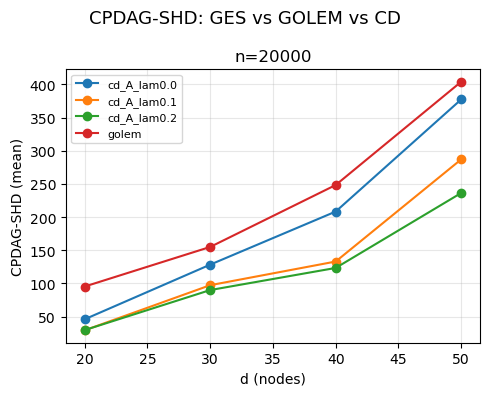

Figure saved.


In [14]:
# 9) Visualization: CPDAG-SHD (faceted by n_samples)
if 'df_all_summary' not in dir() or len(df_all_summary) == 0:
    print('Please run cell 8 first.')
else:
    metric = 'cpdag_shd_mean'
    n_list_plot = sorted(df_all_summary['n_samples'].unique())
    d_list_plot = sorted(df_all_summary['d'].unique())

    fig, axes = plt.subplots(
        1, len(n_list_plot),
        figsize=(5 * len(n_list_plot), 4),
        sharey=True,
    )
    if len(n_list_plot) == 1:
        axes = [axes]

    for ax, n in zip(axes, n_list_plot):
        sub = df_all_summary[df_all_summary['n_samples'] == n]
        piv = sub.pivot(index='d', columns='algorithm', values=metric)
        for alg in piv.columns:
            ax.plot(piv.index, piv[alg], marker='o', label=alg)
        ax.set_title(f'n={n}')
        ax.set_xlabel('d (nodes)')
        ax.set_ylabel('CPDAG-SHD (mean)')
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

    fig.suptitle('CPDAG-SHD: GES vs GOLEM vs CD', fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, 'er_benchmark_cpdag_shd.png'), dpi=150)
    plt.show()
    print('Figure saved.')


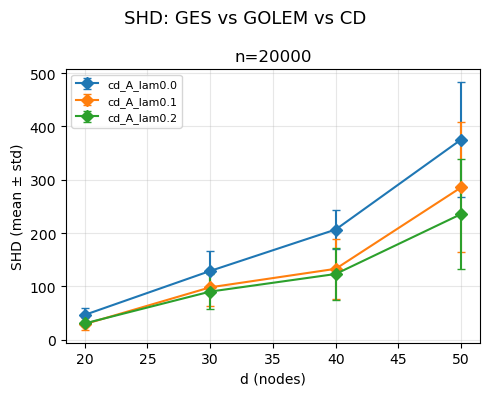

Figure saved.


In [10]:
# 9b) Visualization: SHD (faceted by n_samples)
if 'df_all_summary' not in dir() or len(df_all_summary) == 0:
    print('Please run cell 8 first.')
else:
    metric = 'shd_mean'
    n_list_plot = sorted(df_all_summary['n_samples'].unique())

    fig, axes = plt.subplots(
        1, len(n_list_plot),
        figsize=(5 * len(n_list_plot), 4),
        sharey=True,
    )
    if len(n_list_plot) == 1:
        axes = [axes]

    for ax, n in zip(axes, n_list_plot):
        sub = df_all_summary[df_all_summary['n_samples'] == n]
        piv = sub.pivot(index='d', columns='algorithm', values=metric)
        err = sub.pivot(index='d', columns='algorithm', values='shd_std')
        for alg in piv.columns:
            y    = piv[alg]
            yerr = err[alg] if alg in err.columns else None
            ax.errorbar(piv.index, y, yerr=yerr, marker='D', capsize=3, label=alg)
        ax.set_title(f'n={n}')
        ax.set_xlabel('d (nodes)')
        ax.set_ylabel('SHD (mean ± std)')
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

    fig.suptitle('SHD: GES vs GOLEM vs CD', fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, 'er_benchmark_shd.png'), dpi=150)
    plt.show()
    print('Figure saved.')


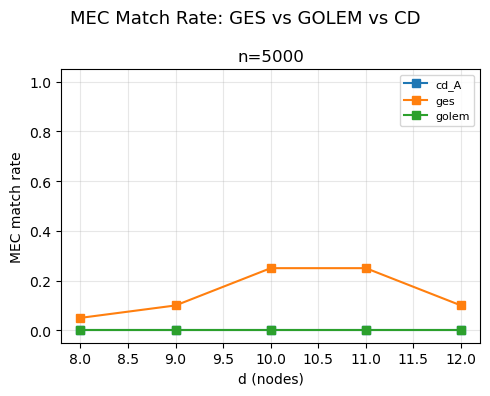

Figure saved.


In [ ]:
# # 10) Visualization: MEC match rate
# if 'df_all_summary' not in dir() or len(df_all_summary) == 0:
#     print('Please run cell 8 first.')
# else:
#     metric = 'mec_match_rate'
#     n_list_plot = sorted(df_all_summary['n_samples'].unique())

#     fig, axes = plt.subplots(1, len(n_list_plot),
#                               figsize=(5 * len(n_list_plot), 4), sharey=True)
#     if len(n_list_plot) == 1:
#         axes = [axes]

#     for ax, n in zip(axes, n_list_plot):
#         sub = df_all_summary[df_all_summary['n_samples'] == n]
#         piv = sub.pivot(index='d', columns='algorithm', values=metric)
#         for alg in piv.columns:
#             ax.plot(piv.index, piv[alg], marker='s', label=alg)
#         ax.set_title(f'n={n}')
#         ax.set_xlabel('d (nodes)')
#         ax.set_ylabel('MEC match rate')
#         ax.set_ylim(-0.05, 1.05)
#         ax.legend(fontsize=8)
#         ax.grid(alpha=0.3)

#     fig.suptitle('MEC Match Rate: GES vs GOLEM vs CD', fontsize=13)
#     plt.tight_layout()
#     plt.savefig(os.path.join(OUT_DIR, 'er_benchmark_mec_match.png'), dpi=150)
#     plt.show()
#     print('Figure saved.')


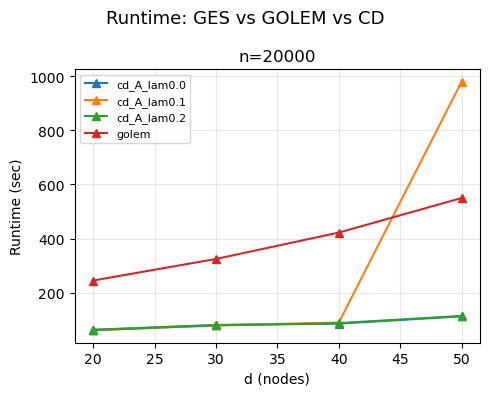

Figure saved.


In [15]:
# 11) Visualization: runtime
if 'df_all_summary' not in dir() or len(df_all_summary) == 0:
    print('Please run cell 8 first.')
else:
    metric = 'runtime_sec_mean'
    n_list_plot = sorted(df_all_summary['n_samples'].unique())

    fig, axes = plt.subplots(1, len(n_list_plot),
                              figsize=(5 * len(n_list_plot), 4), sharey=False)
    if len(n_list_plot) == 1:
        axes = [axes]

    for ax, n in zip(axes, n_list_plot):
        sub = df_all_summary[df_all_summary['n_samples'] == n]
        piv = sub.pivot(index='d', columns='algorithm', values=metric)
        for alg in piv.columns:
            ax.plot(piv.index, piv[alg], marker='^', label=alg)
        ax.set_title(f'n={n}')
        ax.set_xlabel('d (nodes)')
        ax.set_ylabel('Runtime (sec)')
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

    fig.suptitle('Runtime: GES vs GOLEM vs CD', fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, 'er_benchmark_runtime.png'), dpi=150)
    plt.show()
    print('Figure saved.')


In [ ]:
# # 12) Detail table (one row per trial)
# if 'df_all_trials' not in dir() or len(df_all_trials) == 0:
#     print('Please run the benchmark cells first.')
# else:
#     cols_detail = ['algorithm', 'd', 'n_samples', 'trial_id', 'seed',
#                    'status', 'runtime_sec', 'mec_match', 'shd', 'cpdag_shd',
#                    'n_edges_true', 'n_edges_est', 'score_start', 'score_end', 'score_delta']
#     display(
#         df_all_trials[cols_detail]
#         .sort_values(['algorithm', 'd', 'n_samples', 'trial_id'])
#         .reset_index(drop=True)
#     )


,algorithm,d,n_samples,trial_id,seed,status,runtime_sec,mec_match,cpdag_shd,n_edges_true,n_edges_est,score_start,score_end,score_delta
0,cd_A,8,5000,1,89250953,ok,11.193557,0.0,27.0,16,28,4.407994e+06,21.202552,-4.407973e+06
1,cd_A,8,5000,2,773956048,ok,9.111915,0.0,9.0,13,19,1.466819e+06,725.286582,-1.466094e+06
2,cd_A,8,5000,3,654571518,ok,9.933688,0.0,13.0,15,23,5.320902e+07,69.445279,-5.320896e+07
3,cd_A,8,5000,4,438878439,ok,9.569821,0.0,15.0,14,21,2.721292e+06,134.266625,-2.721158e+06
4,cd_A,8,5000,5,433015235,ok,10.426781,0.0,14.0,17,20,2.495875e+07,2009.967063,-2.495674e+07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,golem,12,5000,16,796842586,ok,39.609898,0.0,44.0,23,58,8.619957e+01,61.532374,-2.466719e+01
296,golem,12,5000,17,786924377,ok,39.581381,0.0,NaN,14,33,7.173797e+01,51.194949,-2.054302e+01
297,golem,12,5000,18,780364318,ok,51.335419,0.0,48.0,28,64,1.065077e+02,80.811867,-2.569582e+01
298,golem,12,5000,19,664850856,ok,39.350009,0.0,27.0,16,23,7.667971e+01,51.181056,-2.549865e+01


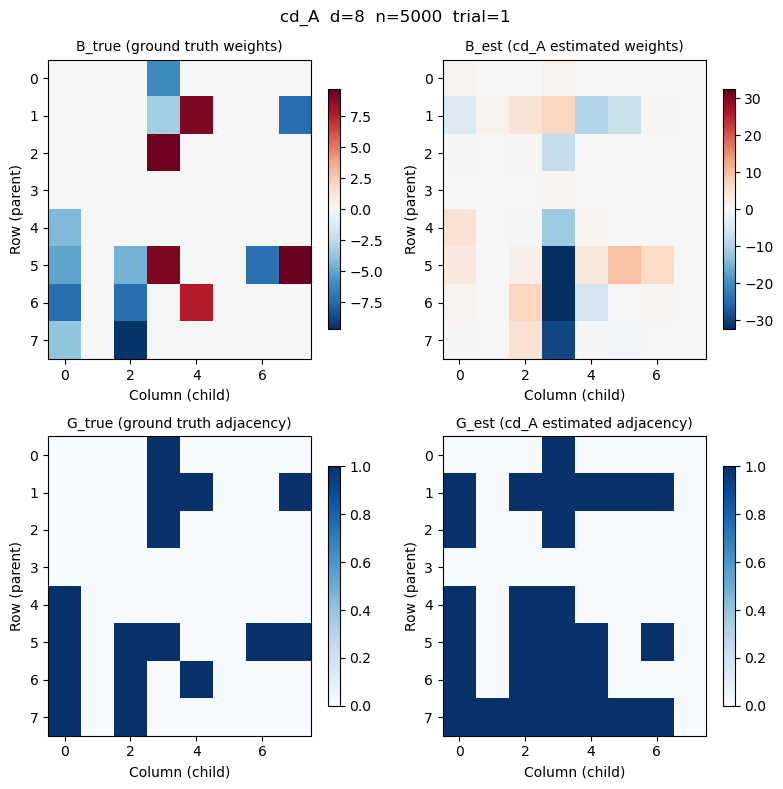

Figure saved: c:\Users\super\DAG\experiments\results\er_benchmark_matrix_cd_A_d8_n5000_t1.png


In [ ]:
# # 13) Heatmap: B_true / G_true vs B_est / G_est (from MATRIX_STORE)
# VIZ_ALGORITHM = 'cd_A'   # 'ges' / 'golem' / 'cd_A'
# VIZ_D         = None      # None = auto-select first d
# VIZ_TRIAL     = 1         # trial index (1-based)

# if 'MATRIX_STORE' not in dir() or len(MATRIX_STORE) == 0:
#     print('MATRIX_STORE is empty. Please run cells 5-7 first.')
# else:
#     avail_keys = [k for k in MATRIX_STORE if k[0] == VIZ_ALGORITHM]
#     if not avail_keys:
#         print(f'No records for algorithm {VIZ_ALGORITHM} in MATRIX_STORE.')
#     else:
#         d_avail = sorted(set(k[1] for k in avail_keys))
#         if VIZ_D is None:
#             VIZ_D = d_avail[0]
#         n_avail = sorted(set(k[2] for k in avail_keys if k[1] == VIZ_D))
#         if not n_avail:
#             print(f'No records for d={VIZ_D}.')
#         else:
#             for n_viz in n_avail:
#                 key = (VIZ_ALGORITHM, VIZ_D, n_viz, VIZ_TRIAL)
#                 if key not in MATRIX_STORE:
#                     print(f'Key {key} not found, skipping.')
#                     continue

#                 mats     = MATRIX_STORE[key]
#                 B_true_v = mats['B_true']
#                 G_true_v = mats['G_true']
#                 B_est_v  = mats['B_est']
#                 G_est_v  = mats['G_est']
#                 has_B    = B_est_v is not None

#                 # 2 rows (B / G) x 2 cols (true / est); GES has no B row
#                 n_rows = 2 if has_B else 1
#                 fig, axes = plt.subplots(n_rows, 2, figsize=(8, 4 * n_rows))
#                 if n_rows == 1:
#                     axes = axes[np.newaxis, :]

#                 def _heatmap(ax, M, title, cmap='RdBu_r'):
#                     if M is None:
#                         ax.set_visible(False)
#                         return
#                     vmax = np.abs(M).max() if np.abs(M).max() > 0 else 1.0
#                     im = ax.imshow(M, cmap=cmap, vmin=-vmax, vmax=vmax, aspect='auto')
#                     ax.set_title(title, fontsize=10)
#                     ax.set_xlabel('Column (child)')
#                     ax.set_ylabel('Row (parent)')
#                     plt.colorbar(im, ax=ax, shrink=0.8)

#                 def _heatmap_binary(ax, M, title):
#                     if M is None:
#                         ax.set_visible(False)
#                         return
#                     im = ax.imshow(M, cmap='Blues', vmin=0, vmax=1, aspect='auto')
#                     ax.set_title(title, fontsize=10)
#                     ax.set_xlabel('Column (child)')
#                     ax.set_ylabel('Row (parent)')
#                     plt.colorbar(im, ax=ax, shrink=0.8)

#                 row = 0
#                 if has_B:
#                     _heatmap(axes[row, 0], B_true_v, 'B_true (ground truth weights)')
#                     _heatmap(axes[row, 1], B_est_v,  f'B_est ({VIZ_ALGORITHM} estimated weights)')
#                     row += 1

#                 _heatmap_binary(axes[row, 0], G_true_v, 'G_true (ground truth adjacency)')
#                 _heatmap_binary(axes[row, 1], G_est_v,  f'G_est ({VIZ_ALGORITHM} estimated adjacency)')

#                 fig.suptitle(
#                     f'{VIZ_ALGORITHM}  d={VIZ_D}  n={n_viz}  trial={VIZ_TRIAL}',
#                     fontsize=12,
#                 )
#                 plt.tight_layout()
#                 out_png = os.path.join(OUT_DIR,
#                     f'er_benchmark_matrix_{VIZ_ALGORITHM}_d{VIZ_D}_n{n_viz}_t{VIZ_TRIAL}.png')
#                 plt.savefig(out_png, dpi=150)
#                 plt.show()
#                 print(f'Figure saved: {out_png}')
